# Unilever Supply Chain Data Analysis

# Load Library

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

The dataset used was downloaded from Kaggle - https://www.kaggle.com/datasets/rahuljangir78/unilever-supply-chain-analysis

In [223]:
df = pd.read_excel('Unilever_SCM_data.xlsx') 
df.head()

,Date,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,...,Supplier name,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,2023-01-01,skincare,SKU1955,48.61,23,318,8232.01,Unknown,40,15,...,Supplier 4,13,492,7,69.84,Pending,2.6997,Air,Route C,562.43
1,2023-01-01,haircare,SKU2712,36.15,84,566,2652.16,Male,78,24,...,Supplier 1,15,426,8,72.63,Fail,2.4737,Road,Route A,267.91
2,2023-01-01,skincare,SKU2979,47.31,67,323,8016.56,Unknown,85,24,...,Supplier 5,15,839,12,90.35,Fail,1.3163,Sea,Route B,545.74
3,2023-01-01,haircare,SKU642,56.37,49,150,3299.79,Female,11,16,...,Supplier 2,13,407,20,47.20,Pass,1.9604,Air,Route A,708.32
4,2023-01-02,haircare,SKU1148,1.95,78,768,3147.86,Unknown,73,9,...,Supplier 5,5,200,17,65.37,Fail,2.0382,Rail,Route B,298.31


In [225]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,3000,2023-12-31 11:27:50.399999744,2023-01-01 00:00:00,2023-06-30 18:00:00,2023-12-31 12:00:00,2024-06-30 06:00:00,2024-12-31 00:00:00,NaN
Price,3000.0,49.901923,1.7,29.1675,50.46,70.48,99.17,24.824732
Availability,3000.0,48.273,1.0,29.0,47.0,67.0,100.0,23.959532
Number of products sold,3000.0,462.362333,8.0,274.0,444.0,633.0,996.0,236.484879
Revenue generated,3000.0,5760.703307,1061.62,4007.6825,5834.31,7649.885,9866.47,2158.592666
Stock levels,3000.0,47.814333,0.0,28.0,47.0,67.0,100.0,25.073454
Lead times,3000.0,16.050667,1.0,11.0,16.0,22.0,30.0,7.005745
Order quantities,3000.0,49.269667,1.0,33.0,51.0,65.0,96.0,21.294446
Shipping times,3000.0,5.724,1.0,4.0,6.0,7.0,10.0,2.168269
Shipping costs,3000.0,5.476817,1.01,3.94,5.45,7.09,9.93,2.08802


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     3000 non-null   datetime64[ns]
 1   Product type             3000 non-null   object        
 2   SKU                      3000 non-null   object        
 3   Price                    3000 non-null   float64       
 4   Availability             3000 non-null   int64         
 5   Number of products sold  3000 non-null   int64         
 6   Revenue generated        3000 non-null   float64       
 7   Customer demographics    3000 non-null   object        
 8   Stock levels             3000 non-null   int64         
 9   Lead times               3000 non-null   int64         
 10  Order quantities         3000 non-null   int64         
 11  Shipping times           3000 non-null   int64         
 12  Shipping carriers        3000 non-

In [229]:
df['Customer demographics'].value_counts()

Customer demographics
Unknown       901
Female        740
Non-binary    690
Male          669
Name: count, dtype: int64

In [231]:
df['Shipping carriers'].value_counts()

Shipping carriers
Carrier B    1302
Carrier A     870
Carrier C     828
Name: count, dtype: int64

In [233]:
df['Transportation modes'].value_counts()

Transportation modes
Road    867
Air     823
Rail    819
Sea     491
Name: count, dtype: int64

In [235]:
df['Routes'].value_counts()

Routes
Route A    1284
Route B    1089
Route C     627
Name: count, dtype: int64

In [237]:
df['Product type'].value_counts()

Product type
skincare     1198
haircare     1049
cosmetics     753
Name: count, dtype: int64

In [239]:
df.isnull().sum()

Date                       0
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [241]:
df.columns = [col.strip() for col in df.columns]

print("\nColumn List")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


Column List
1. Date
2. Product type
3. SKU
4. Price
5. Availability
6. Number of products sold
7. Revenue generated
8. Customer demographics
9. Stock levels
10. Lead times
11. Order quantities
12. Shipping times
13. Shipping carriers
14. Shipping costs
15. Supplier name
16. Lead time
17. Production volumes
18. Manufacturing lead time
19. Manufacturing costs
20. Inspection results
21. Defect rates
22. Transportation modes
23. Routes
24. Costs


* **Product Type**: Specifies the category of the product. This helps identify the type of product within the supply chain and its associated costs.
* **SKU**: The unique stock-keeping unit identifier for each product. It helps in tracking and managing inventory.
* **Price**: The retail price of the product. This helps to assess the financial performance of each item.
* **Availability**: The percentage or quantity representing how available the product is within the supply chain, affecting inventory management.
* **Number of Products Sold**: The total quantity of the product sold, used to assess product demand and supply chain efficiency.
* **Revenue Generated**: The total revenue generated by the sales of the product, calculated by multiplying price with the number of units sold.
* **Customer Demographics**: Represents the type of customers purchasing the product (e.g., gender, age), offering insights into demand patterns.
* **Stock Levels**: Indicates the amount of inventory available in stock, helping track inventory efficiency.
* **Lead Times**: The time it takes from order placement to product delivery, affecting costs and operational efficiency.
* **Order Quantities**: The amount of product ordered, indicating the volume of stock needed by the customer.
* **Shipping Times**: The time it takes for products to be shipped, affecting delivery efficiency.
* **Shipping Carriers**: The company responsible for transporting the product, impacting cost and speed of delivery.
* **Shipping Costs**: The total cost incurred for shipping the product, which is a direct operational cost.
* **Supplier Name**: The name of the supplier providing the product, used to evaluate supplier performance.
* **Production Volumes**: The quantity of products produced, indicating the scale of operations and efficiency.
* **Manufacturing Lead Time**: The time required for the manufacturing process, affecting production schedules and costs.
* **Manufacturing Costs**: The cost associated with the production of the item, including labor, raw materials, and energy.
* **Inspection Results**: Outcome of product quality inspections, highlighting any defects or issues that may affect product quality.
* **Defect Rates**: The percentage of products that are defective, impacting waste and overall costs.
* **Transportation Modes**: The methods of transportation used (e.g., road, rail, sea, air), impacting delivery times and emissions.
* **Routes**: The specific routes taken during transportation, affecting delivery efficiency and costs.
* **Costs**: The total operational costs associated with manufacturing, transportation, and distribution.

In [16]:
# what product produces the 
revenue_product = df.groupby("Product type")["Revenue generated"].sum().sort_values(ascending=False)
print(revenue_product)

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64


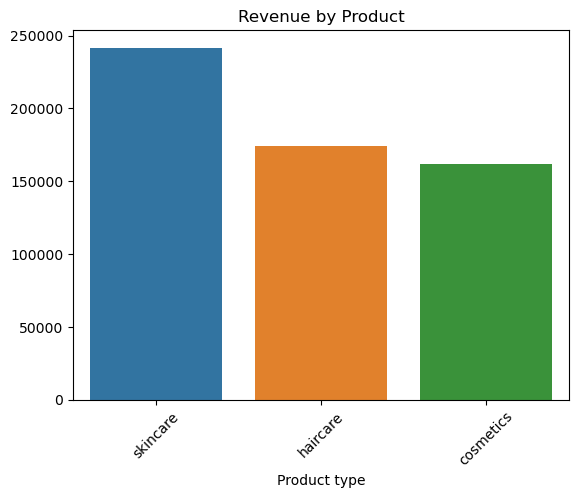

In [20]:
sns.barplot(x=revenue_product.index, y=revenue_product.values)
plt.xticks(rotation=45)
plt.title("Revenue by Product")
plt.show()

In [27]:
# inventory turnover

df["Inventory_turnover"] = np.where(
    df["Stock levels"] != 0, 
    df["Number of products sold"] / df["Stock levels"],
    np.nan
)

In [33]:
# top products with high demand by inventory turnover 

df[["Product type", "Inventory_turnover"]].sort_values("Inventory_turnover", ascending=False)

,Product type,Inventory_turnover
34,skincare,602.000000
47,skincare,227.500000
78,haircare,189.200000
4,skincare,174.200000
33,cosmetics,154.000000
...,...,...
97,haircare,1.347826
49,cosmetics,1.020619
48,haircare,0.966667
45,haircare,0.258065


In [41]:
supplier_lead = df.groupby("Supplier name")["Lead time"].mean().sort_values()
print(supplier_lead)

Supplier name
Supplier 1    14.777778
Supplier 4    15.222222
Supplier 5    18.055556
Supplier 2    18.545455
Supplier 3    20.133333
Name: Lead time, dtype: float64


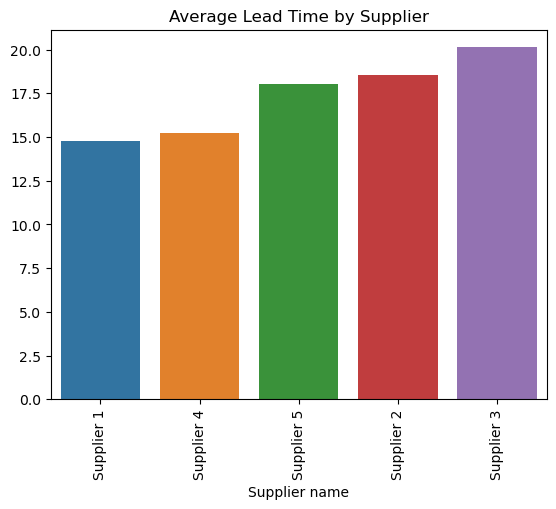

In [43]:
sns.barplot(x=supplier_lead.index, y=supplier_lead.values)
plt.xticks(rotation=90)
plt.title("Average Lead Time by Supplier")
plt.show()

In [46]:
carrier_perf = df.groupby("Shipping carriers")["Shipping times"].mean()

print(carrier_perf)

Shipping carriers
Carrier A    6.142857
Carrier B    5.302326
Carrier C    6.034483
Name: Shipping times, dtype: float64


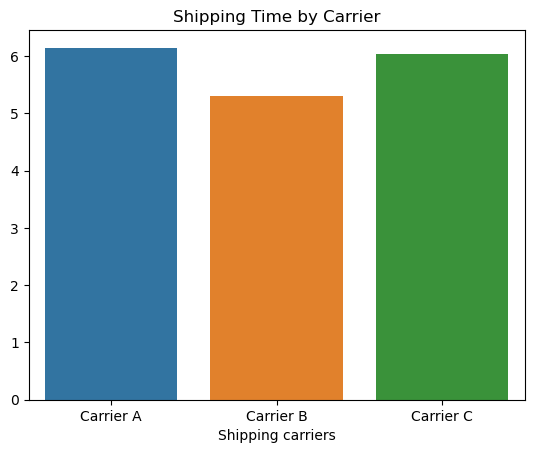

In [48]:
sns.barplot(x=carrier_perf.index, y=carrier_perf.values)
plt.title("Shipping Time by Carrier")
plt.show()

In [51]:
cost_analysis = df.groupby("Product type")[["Manufacturing costs", "Shipping costs"]].mean()
print(cost_analysis)

              Manufacturing costs  Shipping costs
Product type                                     
cosmetics               43.052740        6.060141
haircare                48.457993        5.907757
skincare                48.993157        4.909688


In [54]:
defect_analysis = df.groupby("Product type")["Defect rates"].mean()

print(defect_analysis)

Product type
cosmetics    1.919287
haircare     2.483150
skincare     2.334681
Name: Defect rates, dtype: float64


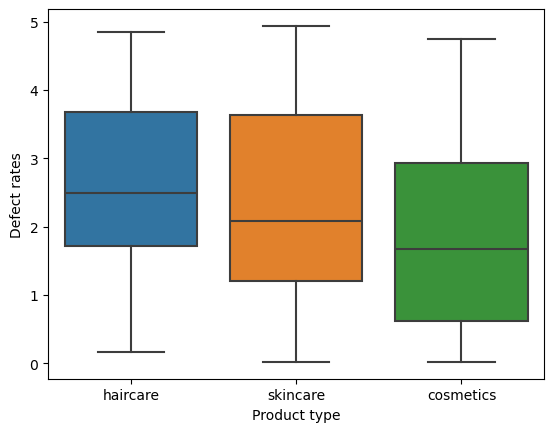

In [56]:
sns.boxplot(x="Product type", y="Defect rates", data=df)
plt.show()

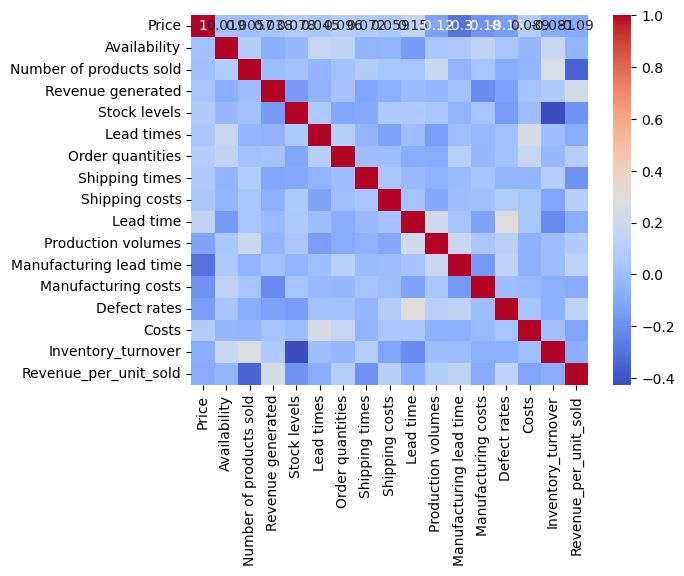

In [59]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Supply Chain Analysis

Derived variables were created to better capture supply chain performance indicators, including inventory efficiency, pricing performance, profitability, production efficiency, and stockout risk.

## 1. Create Derived Variables

1. **Inventory Turnover**: It measures how quickly inventory is sold and replaced.
   * High turnover : efficient inventory management
   * Very low turnover : overstock or low demand
  
2. **Revenue per Unit Sold**: Average revenue generated per unit sold. It helps compare pricing performance between products.

3. **Profit**: It measures actual earnings after costs. 

4. **Profit Margin**: It measures profit as a percentage of revenue, useful to compare profitability across products.

5. **Sales to Production Ratio**: It measures how much of the produced goods are actually sold. It helps detect production inefficiency or waste.

6. **Stock Risk**: It measures whether current inventory is enough to fulfill demand. 





 

In [ ]:
# Inventory turnover 

df["Inventory Turnover"] = np.where(
    df["Stock levels"] != 0, 
    df["Number of products sold"] / df["Stock levels"],
    np.nan
)

# Revenue per Unit Sold 

df["Revenue per Unit Sold"] = np.where(
    df["Number of products sold"] != 0,
    df["Revenue generated"] / df["Number of products sold"], 
    np.nan
)

# Profit 

df["Profit"] = df["Revenue generated"] - df["Costs"]

# Profit Margin 

df["Profit Margin"] = np.where(
    df["Revenue generated"] != 0,
    df["Profit"] / df["Revenue generated"],
    np.nan
)

# Sales to Production Ratio 

df["Sales to Production Ratio"] = np.where(
    df["Production volumes"] != 0, 
    df["Number of products sold"] / df["Production volumes"],
    np.nan
)

# Stock Risk 

df["Stock Risk"] = np.where(
    df["Stock levels"] < df["Order quantities"],
    "Risk",
    "Safe"
)

# Low Stock flag 

stock_threshold = df["Stock levels"].quantile(0.25)
df["Low Stock Flag"] = np.where(df["Stock levels"] <= stock_threshold, "Low", "Normal")

# High stock flag

defect_threshold = df["Defect rates"].quantile(0.75)
df["High Defect Flag"] = np.where(df["Defect rates"] >= defect_threshold, "High", "Normal")


print("\n" + "=" * 80)
print("Derived Variables")
print("=" * 80)

df.head(5)

## 2. Datetime 

We extract 'Year' and 'Month' data from Datetime formet. 

In [295]:
import datetime as dt

In [303]:
# extracting month 

df['Order_month'] = df['Date'].dt.month

In [305]:
# extracting year

df['Order_year'] = df['Date'].dt.year

In [301]:
df.head()

,Date,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,...,Revenue per Unit Sold,Profit,Profit Margin,Sales to Production Ratio,Stock Risk,Low Stock Flag,High Defect Flag,Product Score,Order_month,Order_year
0,2023-01-01,skincare,SKU1955,48.61,23,318,8232.01,Unknown,40,15,...,25.886824,7669.58,0.931678,0.646341,Risk,Normal,Normal,0.392341,1,2023
1,2023-01-01,haircare,SKU2712,36.15,84,566,2652.16,Male,78,24,...,4.685795,2384.25,0.898984,1.328638,Safe,Normal,Normal,0.159968,1,2023
2,2023-01-01,skincare,SKU2979,47.31,67,323,8016.56,Unknown,85,24,...,24.819071,7470.82,0.931923,0.384982,Safe,Normal,Normal,0.437853,1,2023
3,2023-01-01,haircare,SKU642,56.37,49,150,3299.79,Female,11,16,...,21.998600,2591.47,0.785344,0.368550,Risk,Low,Normal,0.091292,1,2023
4,2023-01-02,haircare,SKU1148,1.95,78,768,3147.86,Unknown,73,9,...,4.098776,2849.55,0.905234,3.840000,Safe,Normal,Normal,0.267154,1,2023


## 3. Essential KPI

In [245]:
print("\n" + "=" * 80)
print("Essential KPI")
print("=" * 80)


print("Total revenue:", round(df["Revenue generated"].sum(), 2))

print("Total Costs:", round(df["Costs"].sum(), 2))

print("Total Profit:", round(df["Profit"].sum(), 2))

print("Total Number of products sold:", round(df["Number of products sold"].sum(), 2))

print("AVG Inventory Turnover:", round(df["Inventory Turnover"].mean(), 4))

print("AVG Defect rates:", round(df["Defect rates"].mean(), 4))

print("AVG Lead time:", round(df["Lead time"].mean(), 2))

print("AVG Shipping time:", round(df["Shipping times"].mean(), 2))


Essential KPI
Total revenue: 17282109.92
Total Costs: 1599214.55
Total Profit: 15682895.37
Total Number of products sold: 1387087
AVG Inventory Turnover: 18.1895
AVG Defect rates: 2.3068
AVG Lead time: 17.14
AVG Shipping time: 5.72


## 4. Sale Revenue and Profit by Year and Month

In [334]:
class SalesProfitFunction: 

    def __init__(self, df: pd.DataFrame):
        self._df = df.copy()
        self._validate_data()

    def _validate_data(self):
        required_cols = ['Order_year', 'Order_month', 'Revenue generated', 'Profit']

    def get_revenue_by_year(self) -> pd.DataFrame:
        year_analysis = self._df.groupby('Order_year').agg(
            Total_revenue=('Revenue generated', 'sum'),
            Total_profit=('Profit', 'sum')
        ).reset_index()
        return year_analysis

    def get_revenue_by_month(self) -> pd.DataFrame:
        month_analysis = self._df.groupby(['Order_year', 'Order_month']).agg(
            Total_revenue=('Revenue generated', 'sum'),
            Total_profit=('Profit', 'sum')
        ).reset_index()
        month_analysis = month_analysis.sort_values(by=['Order_year', 'Order_month'])
        return month_analysis

**Yaerly Revenue and Profit**

In [326]:
sales_profit_analyzer = SalesProfitFunction(df)

annual_sale_profit = sales_profit_analyzer.get_revenue_by_year()
print("--- Annual Sales and Profit Summary ---")
print(annual_sale_profit)

--- Annual Sales and Profit Summary ---
   Order_year  Total_revenue  Total_profit
0        2023     8625201.19    7815443.26
1        2024     8656908.73    7867452.11


In [340]:
sales_profit_analyzer = SalesProfitFunction(df)

monthly_sale_profit = sales_profit_analyzer.get_revenue_by_month()
print("--- Monthly Sales and Profit Summary ---")
print(monthly_sale_profit)

--- Monthly Sales and Profit Summary ---
    Order_year  Order_month  Total_revenue  Total_profit
0         2023            1      679976.38     614817.64
1         2023            2      730649.94     663863.90
2         2023            3      718459.81     653337.73
3         2023            4      712748.15     641996.13
4         2023            5      728455.51     660910.57
5         2023            6      746951.10     680021.63
6         2023            7      713046.45     646737.19
7         2023            8      734186.77     667355.47
8         2023            9      709088.82     639463.28
9         2023           10      710314.95     641438.58
10        2023           11      745058.67     677280.70
11        2023           12      696264.64     628220.44
12        2024            1      716323.86     648281.51
13        2024            2      696093.89     631841.62
14        2024            3      701906.74     637400.36
15        2024            4      734346.28     

* Total revenue and total profit both increased in 2024 compared with 2023.
* Regarding monthly performance, June generated the highest revenue and profit in 2023. In contrast, May recorded the greatest increase in revenue and profit in 2024. 


## 3. Product Analysis

### 3.1. Total Revenue by Product

In [247]:
# Total Revenue by Product

revenue_by_product = (
        df.groupby("Product type", as_index=False)["Revenue generated"]
        .sum()
        .sort_values(by="Revenue generated", ascending=False)
    )
print("\nTotal Revenue by Product")
print("\n" + "-" * 80)
print(revenue_by_product)


Total Revenue by Product

--------------------------------------------------------------------------------
  Product type  Revenue generated
2     skincare         7239170.76
1     haircare         5342665.69
0    cosmetics         4700273.47


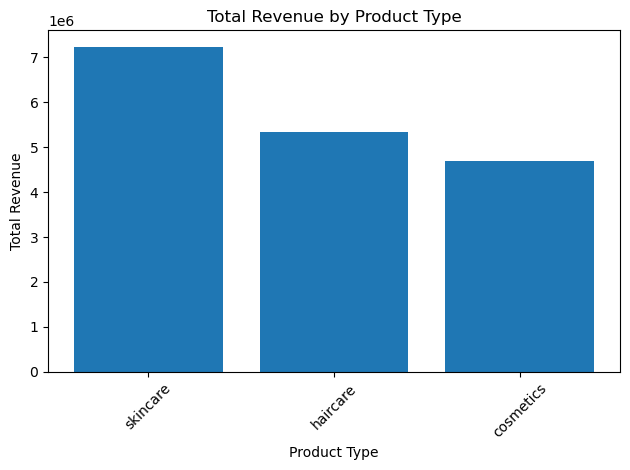

In [249]:
chart = (
    df.groupby("Product type")["Revenue generated"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
plt.bar(chart.index.astype(str), chart.values)
plt.title("Total Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

### 3.2. Total number of products sold

In [251]:
# Total number of products sold

sold_by_product = (
        df.groupby("Product type", as_index=False)["Number of products sold"]
        .sum()
        .sort_values(by="Number of products sold", ascending=False)
    )
print("\nTotal number of products sold")
print("\n" + "-" * 80)
print(sold_by_product)


Total number of products sold

--------------------------------------------------------------------------------
  Product type  Number of products sold
2     skincare                   614563
1     haircare                   430767
0    cosmetics                   341757


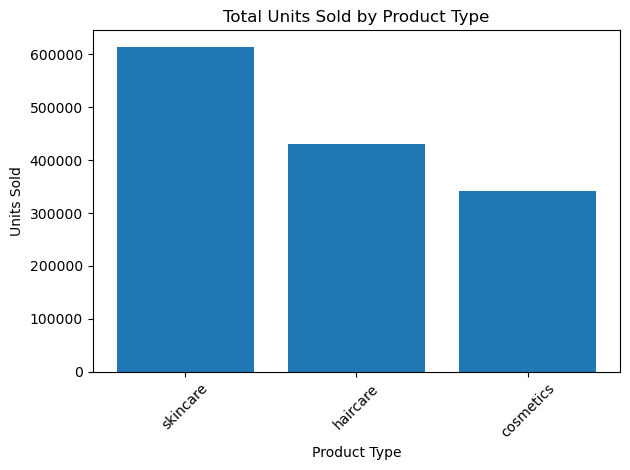

In [253]:
chart = (
        df.groupby("Product type")["Number of products sold"]
        .sum()
        .sort_values(ascending=False)
)

plt.figure()
plt.bar(chart.index.astype(str), chart.values)
plt.title("Total Units Sold by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

### 3.3. Total Profit by product types

In [255]:
# Total Profit by product types

profit_by_product = (
        df.groupby("Product type", as_index=False)["Profit"]
        .sum()
        .sort_values(by="Profit", ascending=False)
    )
print("\nTotal Profit by product types")
print("\n" + "-" * 80)
print(profit_by_product)


Total Profit by product types

--------------------------------------------------------------------------------
  Product type      Profit
2     skincare  6565892.25
1     haircare  4809704.23
0    cosmetics  4307298.89


### 3.4. Average defect rates by product type 

In [261]:
# Average defect rates by product type 

defect_by_product = (
        df.groupby("Product type", as_index=False)["Defect rates"]
        .mean()
        .sort_values(by="Defect rates", ascending=False)
    )
print("\nAverage defect rates by product type")
print("\n" + "-" * 80)
print(defect_by_product)


Average defect rates by product type

--------------------------------------------------------------------------------
  Product type  Defect rates
1     haircare      2.489949
2     skincare      2.358954
0    cosmetics      1.968734


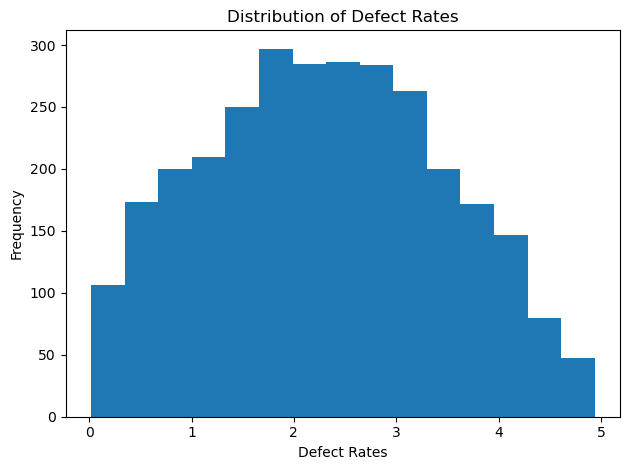

In [263]:
plt.figure()
plt.hist(df["Defect rates"].dropna(), bins=15)
plt.title("Distribution of Defect Rates")
plt.xlabel("Defect Rates")
plt.ylabel("Frequency")
plt.tight_layout()

* Among the three product categories (haircare, skincare, and cosmetics), haircare products exhibit the highest defect rates.
* The distribution of defect rates shows that the majority of products fall within the 1.5 to 3.5 range, whereas defect rates above 4 occur relatively infrequently.

The higher defect rates observed in haircare products suggest potential inefficiencies in production or quality control processes. While most products maintain moderate defect levels, improving quality monitoring and supplier management could help reduce defects, lower operational costs, and enhance overall supply chain efficiency.

### 3.5. Production Volumes

<Figure size 640x480 with 0 Axes>

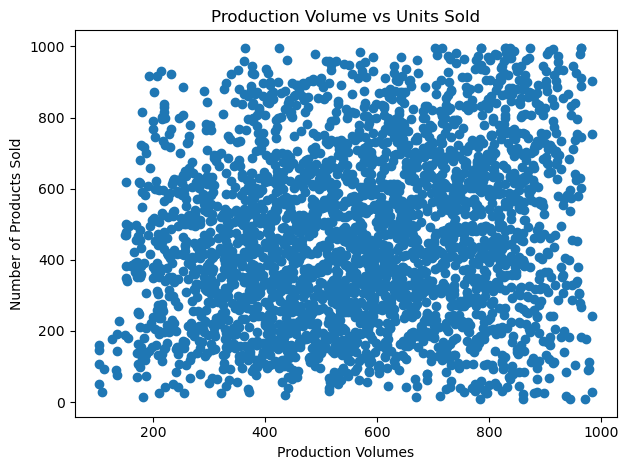

In [265]:
plt.figure()
plt.figure()
plt.scatter(df["Production volumes"], df["Number of products sold"])
plt.title("Production Volume vs Units Sold")
plt.xlabel("Production Volumes")
plt.ylabel("Number of Products Sold")
plt.tight_layout()

## 4. Supply Analysis

### 4.1. Average Lead time by suppliers

In [267]:
# Average Lead time by suppliers

supplier_lead = (
    df.groupby("Supplier name", as_index=False)["Lead time"]
    .mean()
    .sort_values(by="Lead time", ascending=True)
)

print("\nAverage Lead time by suppliers")
print("\n" + "-" * 80)
print(supplier_lead)


Average Lead time by suppliers

--------------------------------------------------------------------------------
  Supplier name  Lead time
4    Supplier 5  16.468571
0    Supplier 1  16.958478
1    Supplier 2  17.053681
3    Supplier 4  17.363985
2    Supplier 3  18.152074


### 4.2. Average Lead Time by Supplier

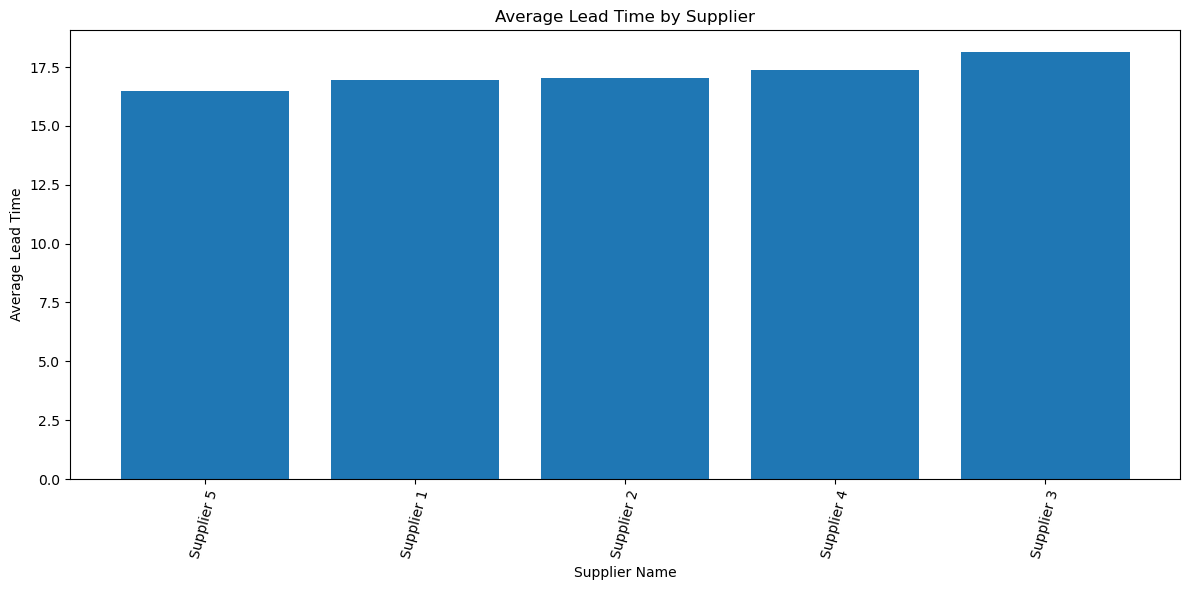

In [269]:
# Average Lead Time by Supplier

chart = (
        df.groupby("Supplier name")["Lead time"]
        .mean()
        .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))
plt.bar(chart.index.astype(str), chart.values)
plt.title("Average Lead Time by Supplier")
plt.xlabel("Supplier Name")
plt.ylabel("Average Lead Time")
plt.xticks(rotation=75)
plt.tight_layout()

### 4.3. Average Costs by suppliers

In [271]:
# Average Costs by suppliers

supplier_cost = (
    df.groupby("Supplier name", as_index=False)["Costs"]
    .mean()
    .sort_values("Costs", ascending=False)
)

print("\nAverage Costs by suppliers")
print("\n" + "-" * 80)
print(supplier_cost)


Average Costs by suppliers

--------------------------------------------------------------------------------
  Supplier name       Costs
3    Supplier 4  539.241628
0    Supplier 1  538.384314
4    Supplier 5  531.721086
1    Supplier 2  526.644356
2    Supplier 3  526.326106


## 5. Shipping/Logistics Analysis

### 5.1. Average shipping times by carriers

In [273]:
# Average shipping times by carriers

carrier_ship = (
        df.groupby("Shipping carriers", as_index=False)["Shipping times"]
        .mean()
        .sort_values(by="Shipping times", ascending=True)
)

print("\nAverage shipping times by carriers")
print("\n" + "-" * 80)
print(carrier_ship)


Average shipping times by carriers

--------------------------------------------------------------------------------
  Shipping carriers  Shipping times
0         Carrier A        5.647126
1         Carrier B        5.725806
2         Carrier C        5.801932


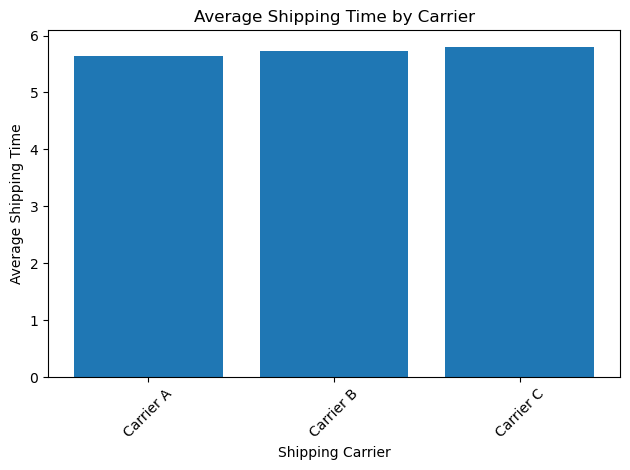

In [275]:
chart = (
        df.groupby("Shipping carriers")["Shipping times"]
        .mean()
        .sort_values(ascending=True)
)

plt.figure()
plt.bar(chart.index.astype(str), chart.values)
plt.title("Average Shipping Time by Carrier")
plt.xlabel("Shipping Carrier")
plt.ylabel("Average Shipping Time")
plt.xticks(rotation=45)
plt.tight_layout()

### 5.2. Average Shipping times by ship mode

In [277]:
# Average Shipping times by ship mode

mode_ship = (
        df.groupby("Transportation modes", as_index=False)["Shipping times"]
        .mean()
        .sort_values(by="Shipping times", ascending=True)
)

print("\nAverage Shipping times by ship mode")
print("\n" + "-" * 80)
print(mode_ship)


Average Shipping times by ship mode

--------------------------------------------------------------------------------
  Transportation modes  Shipping times
2                 Road        5.494810
0                  Air        5.620899
1                 Rail        5.936508
3                  Sea        5.947047


## 6. Stock Risk Analysis

In [279]:
stock_risk_summary = df["Stock Risk"].value_counts().reset_index()
stock_risk_summary.columns = ["Stock Risk", "Count"]
print(stock_risk_summary)

  Stock Risk  Count
0       Risk   1601
1       Safe   1399


In [281]:
risk_items = df[df["Stock levels"] < df["Order quantities"]].copy() 
print("\nStock Risk Items:", risk_items.shape[0])


Stock Risk Items: 1601


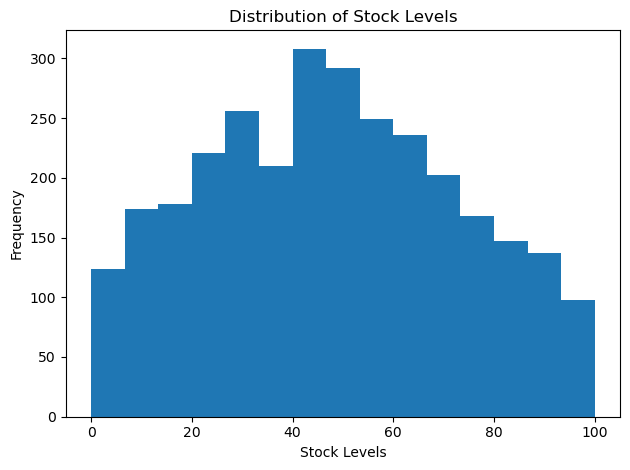

In [283]:
# Stock Level graph

plt.show()
plt.hist(df["Stock levels"].dropna(), bins=15)
plt.title("Distribution of Stock Levels")
plt.xlabel("Stock Levels")
plt.ylabel("Frequency")
plt.tight_layout()

The distribution of stock levels shows that inventory values are spread across a range from 0 to 100 units, with a noticeable concentration around the middle range (40-60 units). This suggests that most products maintain a moderate level of inventory rather than extremely high or low stock quantities. 

However, the stock risk analysis indicates that 1601 products are classified as "at risk", meaning that their stock levels are lower than the corresponding order quantities. In contract, 1399 products are categorized as having safe stock levels, where inventory is sufficient to meet demand. 

## 7. Correlation Analysis

The correlation heatmap provides insights into the relationships between key variables in the supply chain dataset. Overall, most variables show weak to moderate correlations, suggesting that supply chain performance is influenced by multiple factors rather than a single dominant variable.

In [ ]:
numeric_cols_updated = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_updated) > 1:
    corr = df[numeric_cols_updated].corr()
    print(corr.round(3))
    

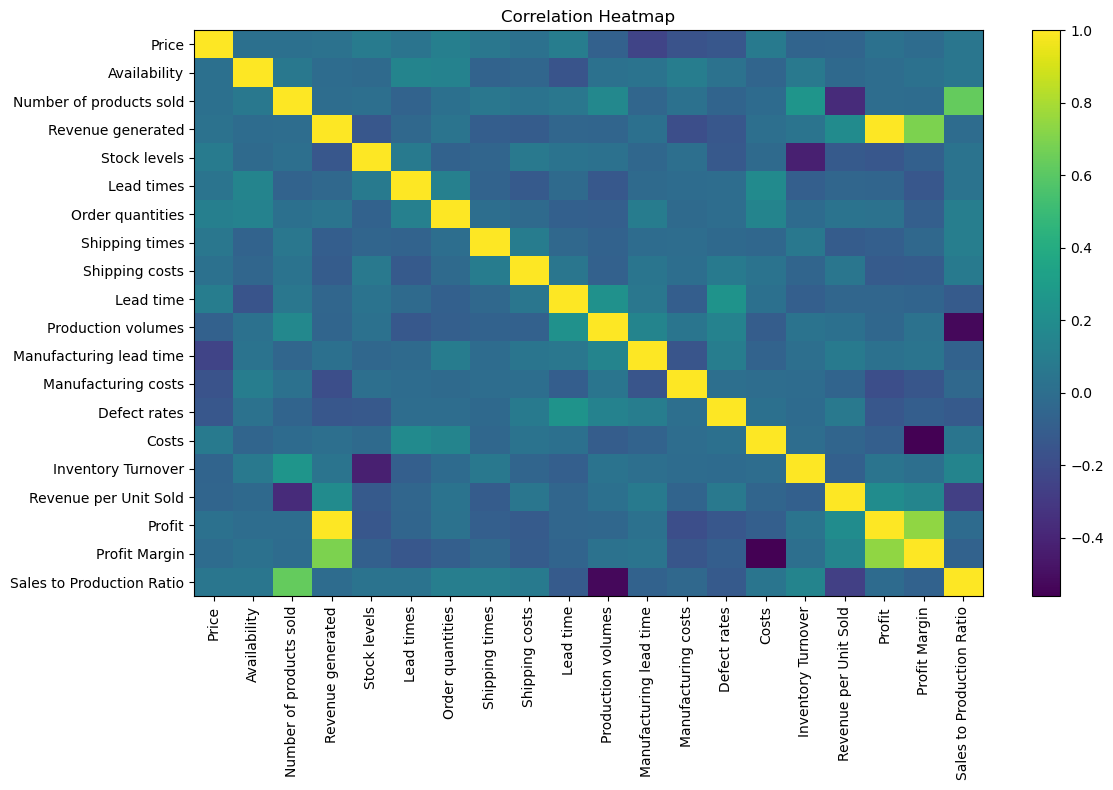

In [287]:
corr_matrix = df[numeric_cols_updated].corr()

plt.figure(figsize=(12, 8))
im = plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(im)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()

**Strong Positive Relationships**

Revenue, Profit, and Profit Margin  
: Revenue generated, profit, and profit margin show strong positive correlations.  
: Higher revenue directly leads to higher profit.  
: It is advisable to focus on high-revenue products, prioritizing in inventory allocation and production planning  

**Sales and Production Relationships**

: Number of products sold is positively correlated with Sales to Production Ratio.  
: As more products are sold, production efficiency improves.  

**Inventory Turnover vs Stock levels**

: Inventory Turnover shows negative correlation with Stock Levels  
: higher stock -> slow turnover, lower stock -> faster turnover   

**Weak Correlations across many variables**

Variables like Lead time, Shipping time, and Defect rates, show relatively weak correlations with revenue or profit. However, Defect rates have noticeable relationships with costs and performance. It indicates that quality issues do not immediately impact revenue but increase operational costs. 

**Conclusion**

The correlation analysis indicates that profitability is primarily driven by revenue, while cost factors negatively impact profit margin, inventory levels and turnover exhibit an inverse relationship, highlighting the need for efficient inventory management. Additionally, operational factors such as lead time, shipping time, and defect rates show weaker direct relationships with financial performance but remain important for overall supply chain efficiency and risk management. 

## 8. Top Products List

In [289]:
print("\n" + "=" * 80)
print("Top products")
print("=" * 80)

required_cols = ["Revenue generated", "Number of products sold", "Defect rates"]

if all(col in df.columns for col in required_cols):
    
    revenue_scaled = (df["Revenue generated"] - df["Revenue generated"].min()) / (
        df["Revenue generated"].max() - df["Revenue generated"].min() + 1e-9
    )
    sold_scaled = (df["Number of products sold"] - df["Number of products sold"].min()) / (
        df["Number of products sold"].max() - df["Number of products sold"].min() + 1e-9
    )
    defect_scaled = (df["Defect rates"] - df["Defect rates"].min()) / (
        df["Defect rates"].max() - df["Defect rates"].min() + 1e-9
    )

    df["Product Score"] = (
        0.5 * revenue_scaled +
        0.3 * sold_scaled -
        0.2 * defect_scaled
    )

    priority_cols = [c for c in ["SKU", "Product type", "Revenue generated",
                                 "Number of products sold", "Defect rates",
                                 "Product Score"] if c in df.columns]

    top_products = df[priority_cols].sort_values(by="Product Score", ascending=False).head(10)
    print(top_products)



Top products
          SKU Product type  Revenue generated  Number of products sold  \
2732  SKU2887     skincare            8756.75                      901   
2781  SKU2860     skincare            9655.14                      832   
614   SKU2440    cosmetics            9692.32                      728   
2352    SKU38    cosmetics            9692.32                      705   
1597  SKU1974     skincare            9135.71                      833   
459   SKU2992    cosmetics            9439.96                      835   
2997   SKU678    cosmetics            9379.34                      753   
2071  SKU2981    cosmetics            9612.22                      715   
1404    SKU88    cosmetics            9444.74                      737   
886   SKU2409    cosmetics            9559.49                      710   

      Defect rates  Product Score  
2732        0.0212       0.708031  
2781        1.0998       0.694257  
614         0.5039       0.689009  
2352        0.6133       0.

**Based on the combination of revenue generated, number of products sold, and defect rates, it was found that skincare product 'SKU2887' product achieved the highest product score '0.708'.** 

In [210]:
df.to_excel("Unilevel_updated.xlsx")